# Chapter 5: The k-Nearest Neighbors Classifiers

This notebook demonstrates how the **k-Nearest Neighbors (k-NN)** algorithm works for both classification and regression.

## 5.1 Introduction

The k-Nearest Neighbors (k-NN) algorithm is a simple, nonparametric method used for both classification and regression.

- **Nonparametric:** It makes no assumptions about the data distribution.
- **Lazy Learning:** The model is built only at the time of prediction.
- **Idea:** For a new sample, find its *k* nearest neighbors and decide its class (or average value) based on them.

- Euclid distance: 

    Given $\mathbf{A} = (x_1, y_1)\, and\, \mathbf{B} = (x_2, y_2)$

    $ d(\mathbf{A}, \mathbf{B}) = \sqrt{(x_1 - x_2)^2 + (y_1 - y_2)^2} $




In [1]:
# Ví dụ ngắn: tính khoảng cách Euclid giữa 2 điểm
import numpy as np

# Hai điểm trong không gian 2D
A = np.array([1, 2])
B = np.array([4, 6])

# Tính khoảng cách Euclid (sqrt((x1-x2)^2 + (y1-y2)^2))
distance = np.linalg.norm(A - B)
print("Euclidean distance between A and B:", distance)

Euclidean distance between A and B: 5.0


## 5.2 Example: k-NN Classification on Iris Dataset

We will use the **Iris dataset** from `sklearn.datasets` to illustrate how k-NN performs classification.

- Split the dataset into training and test sets.
- Train the `KNeighborsClassifier`.
- Evaluate accuracy and classification report.

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



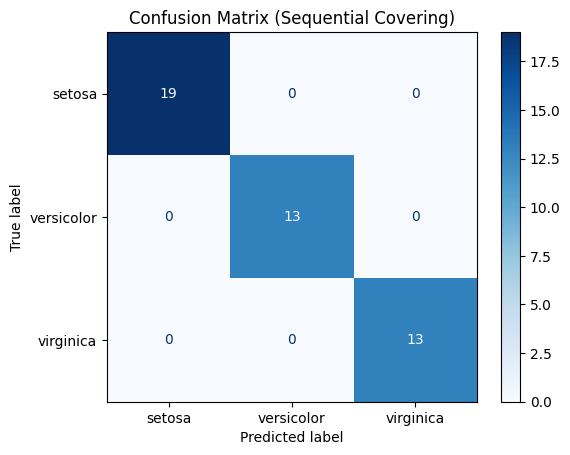

In [6]:
# Import thư viện cần thiết
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

# Tải dữ liệu Iris
X, y = load_iris(return_X_y=True)

# Chia tập dữ liệu thành train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Khởi tạo mô hình kNN với k=5
knn = KNeighborsClassifier(n_neighbors=5)

# Huấn luyện mô hình (fit)
knn.fit(X_train, y_train)

# Dự đoán (predict)
y_pred = knn.predict(X_test)

# Đánh giá mô hình
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Vẽ confusion matrix
y_true = y_test
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["setosa", "versicolor", "virginica"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix (Sequential Covering)")
plt.show()

## 5.3 Weighted Voting

Sometimes, closer neighbors should have a greater influence on the prediction.

We can use `weights='distance'` to make closer points more important.

In [7]:
# Thử nghiệm với cách bỏ phiếu có trọng số
knn_weighted = KNeighborsClassifier(n_neighbors=5, weights='distance')
knn_weighted.fit(X_train, y_train)
y_pred_w = knn_weighted.predict(X_test)

print("Accuracy (weighted):", accuracy_score(y_test, y_pred_w))

Accuracy (weighted): 1.0


## 5.4 k-NN Regression Example

We can also use k-NN for regression, predicting continuous values.
Here we use the **Diabetes dataset**.

In [8]:
# Ví dụ hồi quy với KNN
from sklearn.datasets import load_diabetes
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

# Tải dữ liệu
X, y = load_diabetes(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Mô hình hồi quy KNN
knn_reg = KNeighborsRegressor(n_neighbors=5)
knn_reg.fit(X_train, y_train)

# Dự đoán
y_pred_reg = knn_reg.predict(X_test)
mse = mean_squared_error(y_test, y_pred_reg)
print("Mean Squared Error:", mse)

Mean Squared Error: 3222.117894736842


## 5.5 Visualization of Decision Boundaries

To visualize how k-NN divides the feature space, let's plot the decision regions using only two features of Iris dataset.

d:\python\.venvs\py312\Lib\site-packages\sklearn\utils\multiclass.py:213: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  y_type = type_of_target(y, input_name="y")


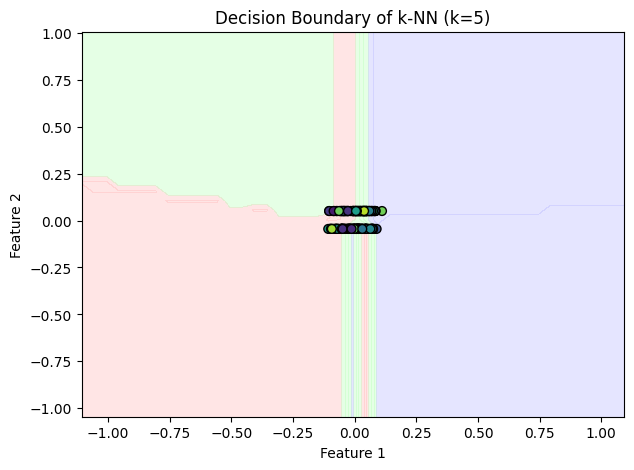

In [9]:
# Trực quan hóa biên phân loại KNN (2 thuộc tính đầu tiên)
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Lấy 2 thuộc tính đầu tiên
X = X_train[:, :2]
y = y_train

# Huấn luyện lại mô hình cho dễ trực quan
knn2d = KNeighborsClassifier(n_neighbors=5)
knn2d.fit(X, y)

# Tạo lưới điểm để vẽ vùng
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05), np.arange(y_min, y_max, 0.05))
Z = knn2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(7,5))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=ListedColormap(['#FFAAAA','#AAFFAA','#AAAAFF']))
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k', s=40)
plt.title('Decision Boundary of k-NN (k=5)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

## 5.6 Summary

- k-NN is simple yet powerful for classification and regression.
- Works well with small datasets.
- No training step, but slow for prediction on large data.
- Sensitive to irrelevant features and feature scaling.
- Main parameters to tune:
  - Number of neighbors (*k*)
  - Distance metric
  - Weighting method